### 感知机

- 给定输入 $\mathbf{x}$，权重 $\mathbf{w}$ 和偏移 $b$，感知机输出：

$$
o = \sigma(\langle \mathbf{w}, \mathbf{x} \rangle + b)
$$

$$
\sigma(x) = 
\begin{cases}
1 & \text{if } x > 0 \\
-1 & \text{otherwise}
\end{cases}
$$

- 二分类：-1 或 1
  - Vs. 回归输出实数
  - Vs. Softmax 回归输出概率

### 收敛定理

- 数据在半径 $r$ 内
- 余量 $\rho$ 分类两类

$$
y(\mathbf{x}^\top \mathbf{w} + b) \geq \rho
$$

对于 $\|\mathbf{w}\|^2 + b^2 \leq 1$

- 感知机保证在 $\dfrac{r^2 + 1}{\rho^2}$ 步后收敛

### 总结

- 感知机是一个二分类模型，是最早的 AI 模型之一
- 它的求解算法等价于使用批量大小为 1 的梯度下降
- 它不能拟合 XOR 函数，导致的第一次 AI 寒冬

### 多层感知机

### 单隐藏层 — 单分类

- 输入 $\mathbf{x} \in \mathbb{R}^n$
- 隐藏层 $\mathbf{W}_1 \in \mathbb{R}^{m \times n}$，$\mathbf{b}_1 \in \mathbb{R}^m$
- 输出层 $\mathbf{w}_2 \in \mathbb{R}^m$，$b_2 \in \mathbb{R}$

$$
\mathbf{h} = \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1)
$$

$$
o = \mathbf{w}_2^\top \mathbf{h} + b_2
$$

$\sigma$ 是按元素的激活函数

### Sigmoid 激活函数

将输入投影到 $(0, 1)$，是一个“软”的 $\sigma(x)$：

$$
\sigma(x) = 
\begin{cases}
1 & \text{if } x > 0 \\
0 & \text{otherwise}
\end{cases}
$$

$$
\mathrm{sigmoid}(x) = \frac{1}{1 + \exp(-x)}
$$

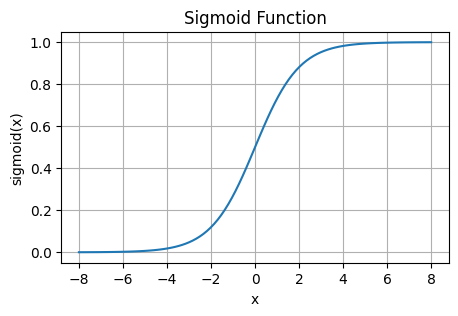

In [2]:
import torch
import matplotlib.pyplot as plt

x = torch.linspace(-8, 8, 100)
y = 1 / (1 + torch.exp(-x))

plt.figure(figsize=(5,3))
plt.plot(x.numpy(), y.numpy())
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.title('Sigmoid Function')
plt.grid(True)
plt.show()


### Tanh 激活函数

将输入投影到 $(-1, 1)$

$$
\tanh(x) = \frac{1 - \exp(-2x)}{1 + \exp(-2x)}
$$

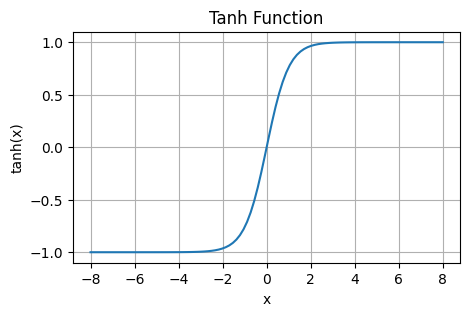

In [4]:
import torch
import matplotlib.pyplot as plt

x = torch.linspace(-8, 8, 100)
y = torch.tanh(x)

plt.figure(figsize=(5,3))
plt.plot(x.numpy(), y.numpy())
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.title('Tanh Function')
plt.grid(True)
plt.show()

### ReLU 激活函数

ReLU: rectified linear unit

$$
\mathrm{ReLU}(x) = \max(x, 0)
$$

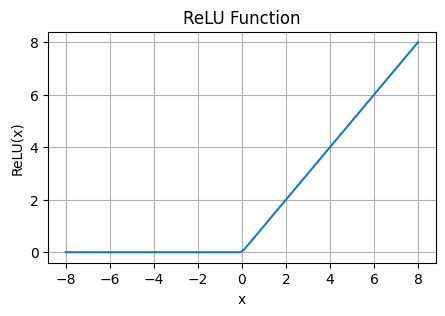

In [5]:
import torch
import matplotlib.pyplot as plt

x = torch.linspace(-8, 8, 100)
y = torch.relu(x)

plt.figure(figsize=(5,3))
plt.plot(x.numpy(), y.numpy())
plt.xlabel('x')
plt.ylabel('ReLU(x)')
plt.title('ReLU Function')
plt.grid(True)
plt.show()

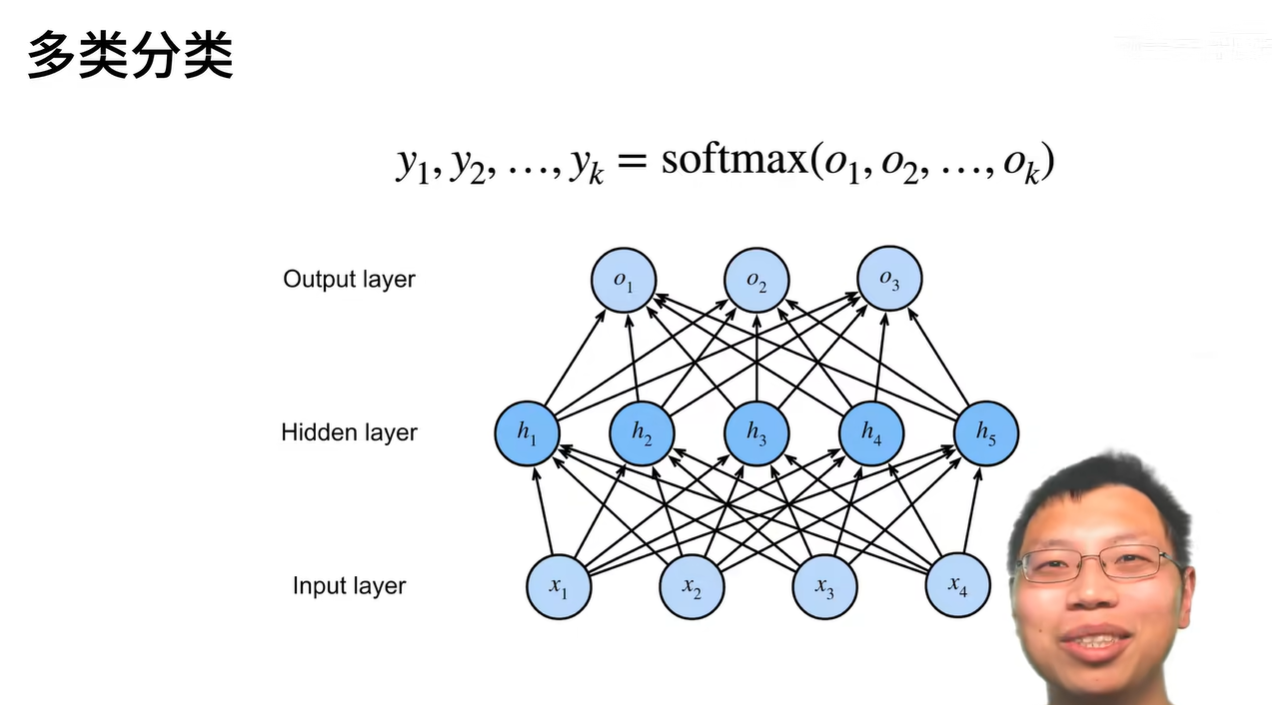

### 多类分类

- 输入 $\mathbf{x} \in \mathbb{R}^n$
- 隐藏层 $\mathbf{W}_1 \in \mathbb{R}^{m \times n}$，$\mathbf{b}_1 \in \mathbb{R}^m$
- 输出层 $\mathbf{W}_2 \in \mathbb{R}^{m \times k}$，$\mathbf{b}_2 \in \mathbb{R}^k$

$$
\mathbf{h} = \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1)
$$

$$
\mathbf{o} = \mathbf{W}_2^\top \mathbf{h} + \mathbf{b}_2
$$

$$
\mathbf{y} = \mathrm{softmax}(\mathbf{o})
$$

### 总结

- 多层感知机使用隐藏层和激活函数数来得到非线性模型
- 常用激活函数是 Sigmoid、Tanh、ReLU
- 使用 Softmax 来处理多类分类
- 超参数为隐藏层数，以及各个隐藏层大小

### 多层感知机的简洁实现

In [24]:
import torch
from torch import nn

#### 隐藏层包含256个隐藏单元，并使用ReLU激活函数

In [16]:
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)